# 1. Setup and Data Loading
Importing libraries and loading the dataset.

In [22]:
import pgeocode
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
import requests
import numpy as np
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from geopy.geocoders import Nominatim
import pmdarima as pm

In [2]:
df = pd.read_csv('complaints_sampled.csv')
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2024-12-10,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,XXXX Account Number : XXXX Balance : {$1500.00...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,CA,92240,NaN,Web,2024-12-10,Closed with explanation,Yes,11080955.0
1,2026-01-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",NC,27127,NaN,Web,2026-01-10,Closed with explanation,Yes,18618561.0
2,2015-12-30,Debt collection,I do not know,Cont'd attempts collect debt not owed,Debt is not mine,I am a victim of Identity theft and I have sen...,NaN,AFNI INC.,CA,94621,NaN,Web,2015-12-30,Closed with explanation,Yes,1722629.0
3,2025-12-22,Vehicle loan or lease,Loan,Incorrect information on your report,Account information incorrect,NaN,NaN,"American Credit Acceptance, LLC",TN,38111,NaN,Referral,2025-12-22,Closed with explanation,Yes,18227443.0
4,2025-05-27,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"EQUIFAX, INC.",TN,37042,NaN,Web,2025-05-27,Closed with non-monetary relief,Yes,13761542.0


# 2. Data Preprocessing
Cleaning data, handling dates, and adding year columns.

In [3]:
#Add year column
#NaT if data is not able to be converted and drop those rows
df['Year'] = pd.to_datetime(df['Date received'], format='mixed', errors = 'coerce').dt.year
print('Shape of the dataframe before dropping year ', df.shape)
df = df.dropna(subset = 'Year')
print('Shape of the dataframe after dropping missing year ', df.shape)


Shape of the dataframe before dropping year  (3974125, 17)
Shape of the dataframe after dropping missing year  (3974124, 17)


# 3. Geocoding Data
Convert ZIP code to longitude and latitude.

In [4]:
nomi = pgeocode.Nominatim('us')

#replace X with 0 to get general location
df['ZIP code'] = df['ZIP code'].fillna('').str.replace('X', '0', regex=False)
unique_zips = df['ZIP code'].unique()
result = nomi.query_postal_code(unique_zips)

zip_to_lat = dict(zip(result['postal_code'], result['latitude']))
zip_to_lon = dict(zip(result['postal_code'], result['longitude']))

df['Latitude'] = df['ZIP code'].map(zip_to_lat)
df['Longitude'] = df['ZIP code'].map(zip_to_lon)

print(f"Geocoded {df['Latitude'].notna().sum():,} / {len(df):,} rows successfully")
#remove empty lat, long data
df = df.dropna(subset = ['Latitude', 'Longitude'])

Geocoded 3,655,185 / 3,974,124 rows successfully


# 4. Population Data
Add population for each state using Census datasets.

In [5]:
url_2019 = "https://www2.census.gov/programs-surveys/popest/datasets/2010-2019/national/totals/nst-est2019-alldata.csv"
url_2025 = "https://www2.census.gov/programs-surveys/popest/datasets/2020-2025/state/totals/NST-EST2025-ALLDATA.csv"

df19 = pd.read_csv(url_2019)
df25 = pd.read_csv(url_2025)

#Remove territories
df19 = df19[df19['SUMLEV'] == 40]
df25 = df25[df25['SUMLEV'] == 40]
df25.sample(5)

,SUMLEV,REGION,DIVISION,STATE,NAME,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,...,RDOMESTICMIG2021,RDOMESTICMIG2022,RDOMESTICMIG2023,RDOMESTICMIG2024,RDOMESTICMIG2025,RNETMIG2021,RNETMIG2022,RNETMIG2023,RNETMIG2024,RNETMIG2025
14,40,3,6,1,Alabama,5025437,5032962,5050058,5076868,5117850,...,5.116523,5.474119,5.841064,4.854242,4.510946,5.475145,7.131285,8.317052,9.153863,6.238616
49,40,2,3,39,Ohio,11799445,11798534,11761443,11764950,11808390,...,-2.757388,-0.585045,0.088659,-0.113144,1.003824,-1.969527,2.447974,4.086057,4.606530,3.403121
50,40,3,7,40,Oklahoma,3959354,3965243,3992760,4025327,4062716,...,6.765768,6.427967,5.606053,3.318925,3.525585,7.313393,9.175006,8.376563,7.901992,5.573987
44,40,1,2,34,New Jersey,9289024,9270476,9266509,9298402,9395315,...,-3.702220,-6.698012,-4.462890,-3.756388,-3.928507,-2.111131,1.492816,7.735219,9.054015,1.641181
21,40,3,5,10,Delaware,989950,991890,1005130,1020279,1035354,...,13.700414,12.372810,9.604827,7.710466,6.497399,14.640815,15.424045,14.782794,14.230797,9.789226


In [6]:
cols_2025 = ['NAME'] + [f'POPESTIMATE{year}' for year in range(2020, 2026)]
cols_2019 = ['NAME'] + [f'POPESTIMATE{year}' for year in range(2011, 2020)]

df19 = df19[cols_2019]
df25 = df25[cols_2025]

pop_df = pd.merge(df19, df25, how='left', on ='NAME')
pop_df.columns = ['State'] + list(np.arange(2011,2026))
pop_df.head()

,State,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Alabama,4799069,4815588,4830081,4841799,4852347,4863525,4874486,4887681,4903185,5032962,5050058,5076868,5117850,5163055,5193088
1,Alaska,722128,730443,737068,736283,737498,741456,739700,735139,731545,732906,734590,733659,734654,736537,737270
2,Arizona,6472643,6554978,6632764,6730413,6829676,6941072,7044008,7158024,7278717,7186647,7274022,7370065,7452073,7556424,7623818
3,Arkansas,2940667,2952164,2959400,2967392,2978048,2989918,3001345,3009733,3017804,3014399,3027127,3047429,3069856,3096080,3114791
4,California,37638369,37948800,38260787,38596972,38918045,39167117,39358497,39461588,39512223,39527808,39152927,39125347,39181667,39364774,39355309


In [7]:
#Add abbreviated state names
state_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA', 
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA', 
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO', 
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ', 
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

melted = pop_df.melt(id_vars=  'State', var_name = 'Year', value_name='Population')
melted['State_abrr'] = melted['State'].map(state_abbr)
melted = melted.drop('State', axis = 1)
melted

,Year,Population,State_abrr
0,2011,4799069,AL
1,2011,722128,AK
2,2011,6472643,AZ
3,2011,2940667,AR
4,2011,37638369,CA
...,...,...,...
775,2025,8001020,WA
776,2025,1766147,WV
777,2025,5972787,WI
778,2025,588753,WY


In [8]:
df['Year'].unique()

array([2024., 2026., 2015., 2025., 2023., 2018., 2021., 2022., 2020.,
       2017., 2014., 2019., 2011., 2013., 2016., 2012.])

In [9]:
map_df = df.copy()

unique_issues = map_df['Issue'].dropna().unique().tolist()

min_year = int(map_df['Year'].min()) 
max_year = int(map_df['Year'].max())
def interactive_map(issues, year):
    # Filter the df
    to_plot = map_df[(map_df['Year'] == year) & (map_df['Issue'].isin(issues))]
    
    # Check if the filtered dataframe is empty before plotting
    if to_plot.empty:
        print("No data available for the selected filters.")
        return
        
    fig = px.scatter_map(
        # sample at most 1000 points to avoid crashing if there are too many
        to_plot.sample(min(1000, len(to_plot))),
        lat='Latitude',
        lon='Longitude',
        hover_name='Sub-issue',
        color='Issue',
        zoom=3,
        center={"lat": 39, "lon": -98},  # Center on US
        map_style='carto-positron',
        height=600,
        width = 1200
    )    
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, title=f"Complaints Map in {year}")
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.show()

issues_widget = widgets.SelectMultiple(
    options=unique_issues,
    value=unique_issues[:3],  # Select first 3 by default
    description='Issues',
    disabled=False,
    rows=15,  
)
year_widget = widgets.IntSlider(
    value=max_year,
    min=min_year,
    max=max_year,
    step=1,
    description='Year',
    layout=widgets.Layout(width='800px'),
    continuous_update=False 
)
# 2. Link the function to the widgets without automatically displaying everything yet
out = widgets.interactive_output(interactive_map, {'issues': issues_widget, 'year': year_widget})
# 3. Create the Layout structure
# Left side gets the year slider and the map output stacked vertically
left_column = widgets.VBox([year_widget, out])
# The main UI puts the left column and the issues widget next to each other horizontally
ui = widgets.HBox([left_column, issues_widget])
# 4. Display the final layout
display(ui)

# 5. Exploratory Data Analysis & Interactive Visualizations
Visualizing complaints using Plotly maps.

In [10]:
df_filtered = df[df['Year'] == 2025]
    
#Group by State and count complaints for that year
state_count = df_filtered.groupby(['State', 'Issue'])['Complaint ID'].count().reset_index(name='Complaint Counts')
state_count = state_count.sort_values(by='Complaint Counts', ascending=False)

state_count

,State,Issue,Complaint Counts
590,FL,Incorrect information on your report,106551
2690,TX,Incorrect information on your report,90415
278,CA,Incorrect information on your report,61298
670,GA,Incorrect information on your report,53658
589,FL,Improper use of your report,39848
...,...,...,...
1154,LA,Getting a loan,1
2589,SD,Unauthorized withdrawals or charges,1
3083,WV,Unauthorized withdrawals or charges,1
3079,WV,Trouble using the card,1


In [11]:
def plot_top_states(year):
    # Filter the dataframe for the selected year
    df_filtered = df[df['Year'] == year]
    
    top_10_states = df_filtered['State'].value_counts().nlargest(10).index
    top_10_df = df_filtered[df_filtered['State'].isin(top_10_states)]
    
    state_issue_count = top_10_df.groupby(['State', 'Issue'])['Complaint ID'].count().reset_index(name='Complaint Counts')
    state_issue_count = state_issue_count.sort_values(['State', 'Complaint Counts'], ascending=[True, False])
    
    # assign 'Other' to anything that isn't in the top 5 for that state
    state_issue_count['Rank'] = state_issue_count.groupby('State').cumcount() + 1
    state_issue_count['Issue'] = state_issue_count.apply(
        lambda row: row['Issue'] if row['Rank'] <= 5 else 'Other', axis=1
    )
    
    grouped_counts = state_issue_count.groupby(['State', 'Issue'])['Complaint Counts'].sum().reset_index()
    
    pivot_df = grouped_counts.pivot(index='State', columns='Issue', values='Complaint Counts').fillna(0)
    
    col_sums = pivot_df.sum().sort_values(ascending=False)
    cols = [c for c in col_sums.index if c != 'Other']
    if 'Other' in col_sums.index:
        cols.append('Other')  # Force 'Other' to be the very last column
    pivot_df = pivot_df[cols]
    
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(by='Total', ascending=True).drop(columns='Total')

    # Plot the stacked horizontal bar chart
    ax = pivot_df.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='tab20')
    
    plt.title(f'Top 10 States With Most Complaints in {year} by Issue', pad=15)
    plt.xlabel('Complaint Counts')
    plt.ylabel('State')
    
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.legend(title='Issue', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

available_years = sorted(df['Year'].dropna().unique().astype(int))
# Create the interactive dropdown widget
interact(plot_top_states, year=widgets.IntSlider(
    value=available_years[0],
    min=available_years[0],
    max=available_years[-1], 
    description='Select Year:'
))

interactive(children=(IntSlider(value=2011, description='Select Year:', max=2026, min=2011), Output()), _dom_c…

<function __main__.plot_top_states(year)>

In [12]:
def plot_top_complaints(year):
    #Filter the dataframe for the selected year
    df_filtered = df[df['Year'] == year]
    
    #Group by State and count complaints for that year
    product_count = df_filtered.groupby(['Product'])['Complaint ID'].count().reset_index(name='Complaint Counts')
    product_count = product_count.sort_values(by='Complaint Counts', ascending=False)
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=product_count.iloc[:10],
        y='Product',
        x='Complaint Counts',
        legend=False
    )
    plt.title(f'Top 10 Products by Complaints in {year}', pad=15)
    plt.xlabel('Complaint Counts')
    plt.ylabel('Product') # Fixed label from State to Product
    
    # Intuitive formatting
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

available_years = sorted(df['Year'].dropna().unique().astype(int))
# 4. Create the interactive dropdown widget
interact(plot_top_complaints, year=widgets.IntSlider(value=available_years[0],
    min = available_years[0],
    max = available_years[-1], description='Select Year:'))

interactive(children=(IntSlider(value=2011, description='Select Year:', max=2026, min=2011), Output()), _dom_c…

<function __main__.plot_top_complaints(year)>

In [13]:
# Convert to datetime and extract Year-Month for animation
df['Date received'] = pd.to_datetime(df['Date received'])
df['Year-Month'] = df['Date received'].dt.to_period('W').astype(str)
# Group by month and state
monthly_state_counts = df.groupby(['Year','Year-Month', 'State']).size().reset_index(name='Complaints')
monthly_state_counts = monthly_state_counts.sort_values('Year-Month')
monthly_state_counts=monthly_state_counts.merge(melted, 
                        how = 'left', 
                        left_on=['Year','State'],
                        right_on=['Year','State_abrr']
                        )
monthly_state_counts = monthly_state_counts.dropna(subset='Population')
monthly_state_counts['Complaints per 10k'] = monthly_state_counts['Complaints']/monthly_state_counts['Population'] * 10000


monthly_state_counts

,Year,Year-Month,State,Complaints,Population,State_abrr,Complaints per 10k
0,2011.0,2011-11-28/2011-12-04,AL,1,4799069.0,AL,0.002084
1,2011.0,2011-11-28/2011-12-04,WV,1,1856301.0,WV,0.005387
2,2011.0,2011-11-28/2011-12-04,WI,2,5705288.0,WI,0.003506
3,2011.0,2011-11-28/2011-12-04,WA,2,6826627.0,WA,0.002930
4,2011.0,2011-11-28/2011-12-04,VA,6,8101155.0,VA,0.007406
...,...,...,...,...,...,...,...
35828,2025.0,2025-12-29/2026-01-04,ND,3,799358.0,ND,0.037530
35829,2025.0,2025-12-29/2026-01-04,NC,396,11197968.0,NC,0.353636
35830,2025.0,2025-12-29/2026-01-04,MT,3,1144694.0,MT,0.026208
35831,2025.0,2025-12-29/2026-01-04,OH,253,11900510.0,OH,0.212596


In [14]:
fig = px.choropleth(
    monthly_state_counts,
    locations='State',
    locationmode="USA-states",
    color='Complaints per 10k',
    animation_frame='Year-Month',  # Animates map month-by-month
    scope="usa",
    color_continuous_scale="Reds",
    title="Monthly Complaint Trends in 2025"
)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, width=1000, height=600)
fig.show()

# 6. Time Series Analysis
Decomposing the time series data for trend and seasonality.

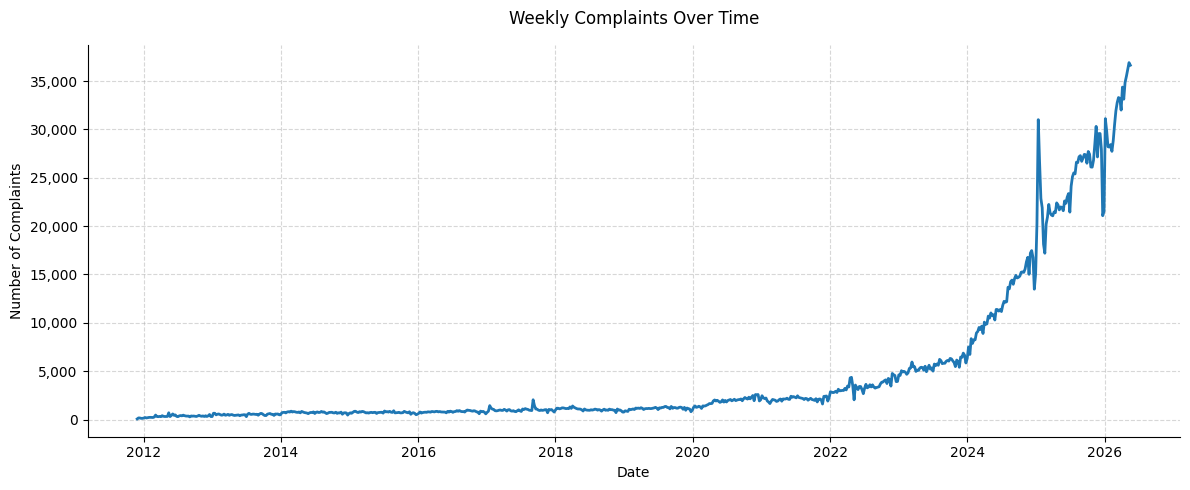

In [15]:
df['Date week'] = df['Date received'].dt.to_period('W').dt.start_time

ts_df = df.groupby('Date week')['Complaint ID'].count().reset_index(name = 'Complaints')
ts_df['Date week'] = pd.to_datetime(ts_df['Date week'])

#remove datapoints 1 week after max due to significant drop in complaints
max_complaints_date = ts_df.loc[ts_df['Complaints'].idxmax(), 'Date week']
cutoff = max_complaints_date + timedelta(weeks = 1)
ts_df_cutoff = ts_df[ts_df['Date week'] <= cutoff]

plt.figure(figsize=(12, 5))
ax = plt.gca()
plt.plot(ts_df_cutoff['Date week'], ts_df_cutoff['Complaints'], marker=None, linestyle='-', markersize=4, linewidth=2)
plt.title('Weekly Complaints Over Time', pad=15)
plt.xlabel('Date')
plt.ylabel('Number of Complaints')

# Intuitive formatting
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\Yooniversity 2.0\AppData\Local\Temp\ipykernel_16992\137692382.py:12: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



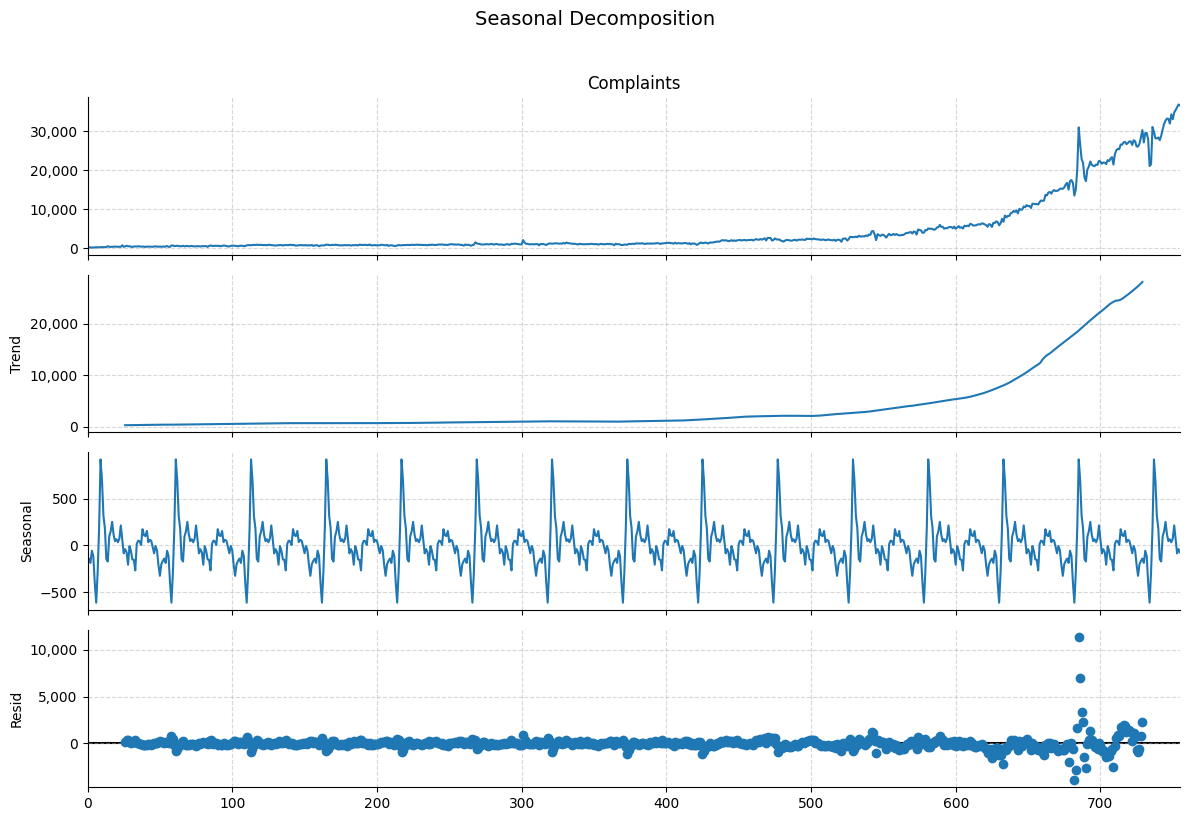

In [16]:
#change period = 52 when running with 2+ years of data
decomp = seasonal_decompose(ts_df_cutoff['Complaints'], model = 'additive', period = 52)
fig = decomp.plot()
fig.set_size_inches(12, 8) # Give the decomposition plots more breathing room
fig.suptitle('Seasonal Decomposition', y=1.02, fontsize=14)
for ax in fig.axes:
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.show()

## 6.1 Complaints Forecasting
Predicting the 2026 forecast using SARIMAX.

In [17]:
ts_ds_pre = ts_df_cutoff[ts_df_cutoff['Date week'].dt.year < 2026]
ts_ds_2026 = ts_df_cutoff[ts_df_cutoff['Date week'].dt.year == 2026]

Display Optimized Model using auto arima

In [23]:
auto_model = pm.auto_arima(
    ts_ds_pre['Complaints'],
    start_p=1, max_p = 3,
    start_q = 1, max_q = 3,
    d = None,
    seasonal= True,
    m = 52, #datset is grouped by week
    start_P = 1, max_P= 2,
    start_Q = 1, max_Q = 2,
    D = 1,
    trace = True,
    stepwise = True, #set true for gridsearch
    StepwiseContext = 15 #test at max 15 searches
)
print(auto_model.summary())

print("Best order:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[52]             : AIC=10837.417, Time=64.60 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=10901.606, Time=1.33 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=10887.089, Time=6.60 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=10890.119, Time=7.19 sec
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=10840.442, Time=38.84 sec
 ARIMA(1,1,1)(1,1,0)[52]             : AIC=10837.714, Time=35.91 sec
 ARIMA(1,1,1)(2,1,1)[52]             : AIC=10837.844, Time=136.98 sec
 ARIMA(1,1,1)(1,1,2)[52]             : AIC=10837.740, Time=136.74 sec
 ARIMA(1,1,1)(0,1,0)[52]             : AIC=10847.957, Time=1.79 sec
 ARIMA(1,1,1)(0,1,2)[52]             : AIC=10836.025, Time=101.29 sec
 ARIMA(0,1,1)(0,1,2)[52]             : AIC=10886.898, Time=42.24 sec
 ARIMA(1,1,0)(0,1,2)[52]             : AIC=10887.221, Time=49.30 sec
 ARIMA(2,1,1)(0,1,2)[52]             : AIC=10813.514, Time=101.52 sec
 ARIMA(2,1,1)(0,1,1)[52]             : AIC=10817.723, Time=4

MemoryError: Unable to allocate 66.8 MiB for an array with shape (109, 109, 737) and data type float64

In [ ]:
# !pip install prophet
from prophet import Prophet
import pandas as pd
# Prophet requires columns to be exactly named 'ds' (dates) and 'y' (values)
df_prophet = ts_ds_pre.reset_index()
df_prophet = df_prophet.rename(columns={'YourDateColumn': 'ds', 'Complaints': 'y'})
m = Prophet(yearly_seasonality=True) # Automatically handles the 52-week cycle
m.fit(df_prophet)
future = m.make_future_dataframe(periods=52, freq='W')
forecast = m.predict(future)
m.plot(forecast)

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



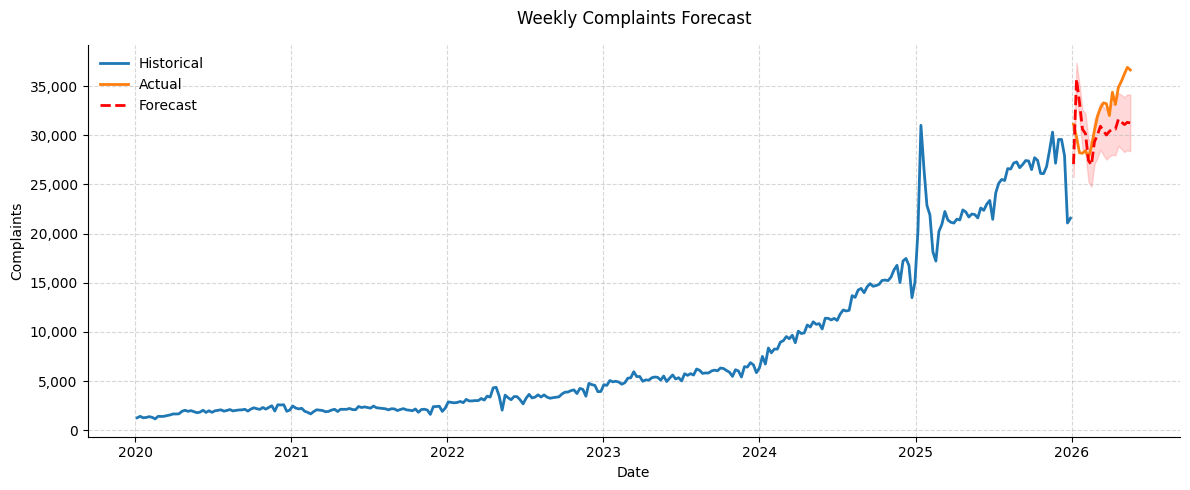

In [ ]:
model = SARIMAX(ts_ds_pre['Complaints'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 52))
results = model.fit(disp=False)

# Forecast the next 12 weeks
forecast_steps = 20
forecast = results.get_forecast(steps=forecast_steps)
forecast_ci = forecast.conf_int()

forecast_idx = []
for week in range(1, forecast_steps +1):
    forecast_idx.append(ts_ds_pre['Date week'].max() + timedelta(weeks = week))

# Plot the forecast. only 2020-2026
begin_date = ts_ds_pre[ts_ds_pre['Date week'].dt.year >=2020]

plt.figure(figsize=(12, 5))
ax = plt.gca()

# Historical
plt.plot(begin_date['Date week'], begin_date['Complaints'], label='Historical', linewidth=2)
# Actual 2026
plt.plot(ts_ds_2026['Date week'], ts_ds_2026['Complaints'], label='Actual', linewidth=2)
# Forecast
plt.plot(forecast_idx, forecast.predicted_mean.values, color='red', label='Forecast', linewidth=2, linestyle='--')
plt.fill_between(forecast_idx, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.15)

plt.title('Weekly Complaints Forecast', pad=15)
plt.xlabel('Date')
plt.ylabel('Complaints')

# Intuitive formatting
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

## 6.2 Model Evaluation
Comparing actual and predicted complaints for validation.

In [ ]:
len(ts_ds_2026['Complaints'])

NameError: name 'ts_ds_2026' is not defined

In [ ]:
pred_df = pd.DataFrame({
    'Date week':ts_ds_2026['Date week'],
    'Prediction': np.round(forecast.predicted_mean.values[:20], 2),
    'Actual': ts_ds_2026['Complaints']
})

pred_df['Difference'] = pred_df['Actual'] - pred_df['Prediction']

pred_df

,Date week,Prediction,Actual,Difference
736,2026-01-05,27065.75,31109,4043.25
737,2026-01-12,35724.80,29847,-5877.80
738,2026-01-19,33348.01,28206,-5142.01
739,2026-01-26,30601.50,28168,-2433.50
740,2026-02-02,30164.48,28426,-1738.48
741,2026-02-09,27423.79,27728,304.21
742,2026-02-16,26977.20,28838,1860.80
743,2026-02-23,29322.78,30472,1149.22
744,2026-03-02,30029.56,31900,1870.44
745,2026-03-09,30913.77,32764,1850.23


## 6.3 Forecast Evaluation Metrics
Calculate Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) to quantify the model's accuracy.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate Evaluation Metrics using the overlapping 2026 predictions
mae = mean_absolute_error(pred_df['Actual'], pred_df['Prediction'])
rmse = np.sqrt(mean_squared_error(pred_df['Actual'], pred_df['Prediction']))
mape = np.mean(np.abs((pred_df['Actual'] - pred_df['Prediction']) / pred_df['Actual'])) * 100

print("FORECAST EVALUATION METRICS (2026)")
print("-" * 40)
print(f"Mean Absolute Error (MAE):             {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):        {rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


FORECAST EVALUATION METRICS (2026)
----------------------------------------
Mean Absolute Error (MAE):             3,183.91
Root Mean Squared Error (RMSE):        3,561.35
Mean Absolute Percentage Error (MAPE): 9.76%
